# Notebook to plot site data
The below code is used to plot data from experimental activities. The dust distribution is currently assumed and its parameters are defined in the file `parameters_wodonga_experiments.xlsx`.

In [1]:
import numpy as np
import soiling_model as sm
import os
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import (rcParams,dates)
import pickle
import copy
rcParams['figure.figsize'] = (30, 10)
rcParams['axes.grid'] = True

fig_size = 50 # fontsize of suptitle, all others fontsize are a fraction of this
mle_save_file = "results/mle_fitting_results"
reflectometer_angle = 15 # angle of incidence of reflectometer
second_surf = True # use first surface model
k_factor = 1 # k_factor in the device (for Ecotech only - no Wodonga)
d = "data/confidential/wodonga_experiments/"
# files = ['experiment_20220421_20220427.xlsx','experiment_20220220_20220226.xlsx']
files = ['experiment_20220421_20220427.xlsx']
parameter_file = d+"parameters_wodonga_experiments.xlsx"

## Multiple experiment reflectance import

In [2]:
files_experiment = [d+files[ii] for ii in range(len(files))]
Nfiles = len(files_experiment)
k_factors = [k_factor]*Nfiles
incidence_angle = [15.0]*Nfiles
extract = lambda x,ind: [x[ii] for ii in ind]

imodel = sm.fitting_experiment(parameter_file)
sim_data_total = sm.simulation_inputs(files_experiment,k_factors=k_factors,dust_type="PM10")
reflect_data_total = sm.reflectance_measurements(files_experiment,sim_data_total.time,number_of_measurements=9.0,\
    reflectometer_incidence_angle=incidence_angle,import_tilts=True,column_names_to_import=None)


Importing constants
Importing dust
Importing site data (weather,time). Using dust_type = PM10, test_length = 142 hours
Length of simulation for file data/confidential/wodonga_experiments/experiment_20220421_20220427.xlsx: 5.0 days
No DNI data to import. Skipping.
Importing rain intensity data...
Importing site data (weather,time). Using dust_type = PM10, test_length = 301 hours
Length of simulation for file data/confidential/wodonga_experiments/experiment_20220220_20220226.xlsx: 12.0 days
No DNI data to import. Skipping.
Importing rain intensity data...


Setting tilts for 2 experiments
Second surface model
Second surface model


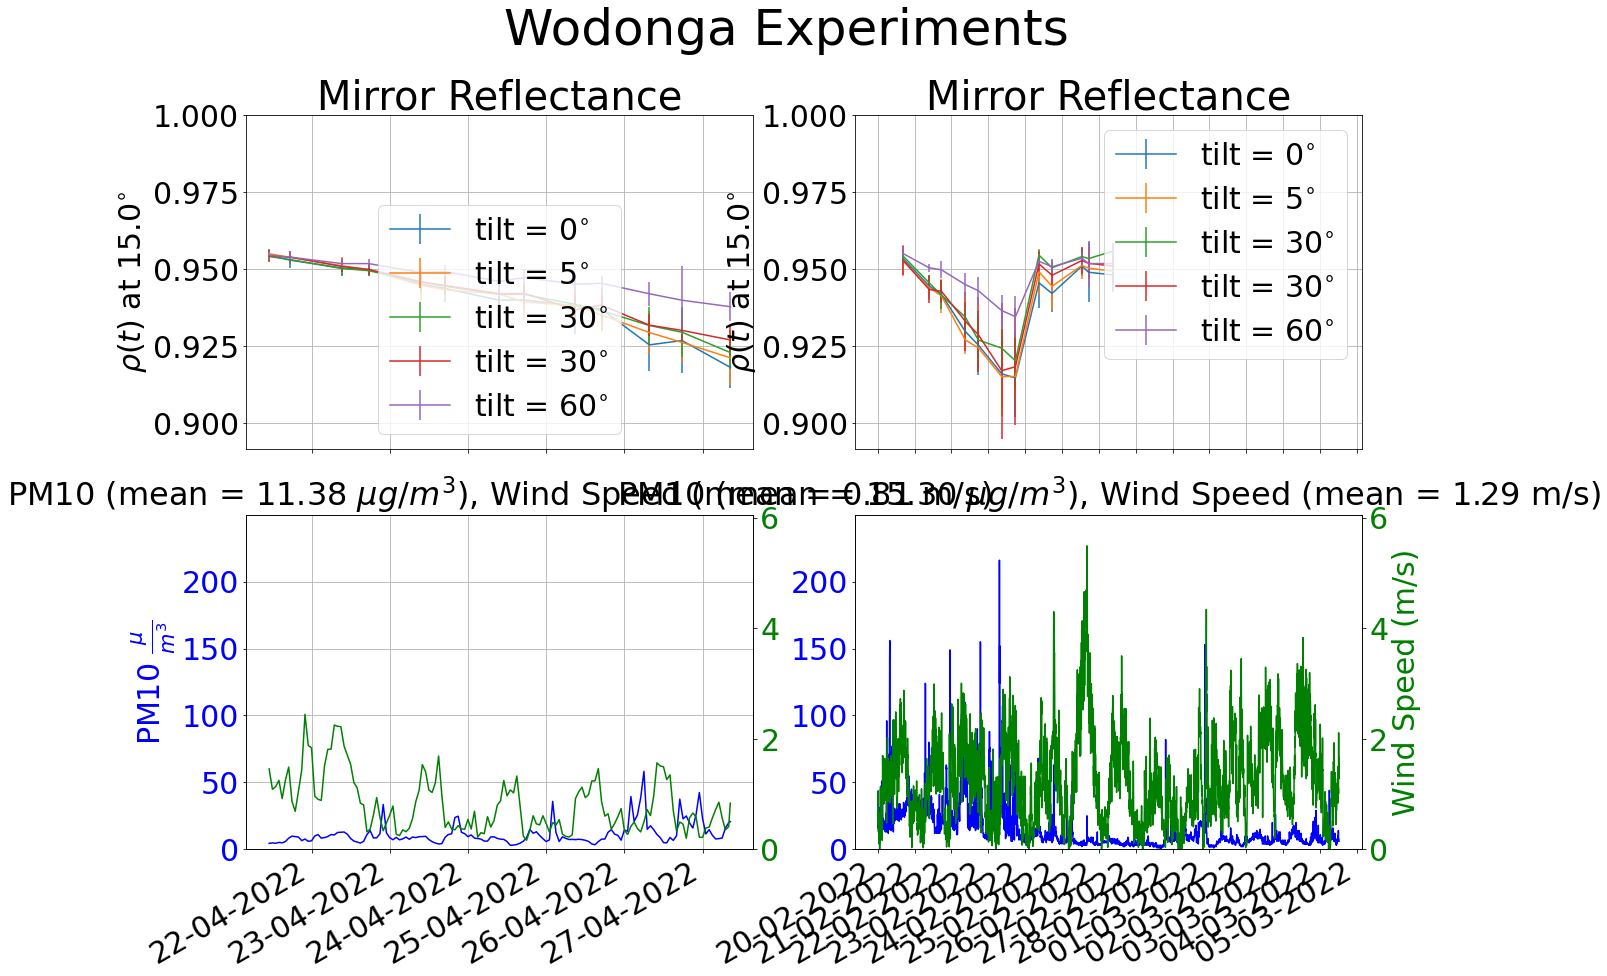

In [3]:
imodel.helios_angles(sim_data_total,reflect_data_total,second_surface=second_surf)
fig = imodel.plot_soiling_factor_all(sim_data_total,reflectance_data=reflect_data_total,figsize=(20,15),reflectance_std='measurements',fig_title="Wodonga Experiments",font_size=fig_size);

In [5]:
fig
fig.savefig('new2',facecolor='white', transparent=False)